# 03 Modeling — 학습 · 선택 · 평가
- 과제: 초기 100사이클 데이터로 배터리 수명(cycle_life) **회귀** · 지표 **MAPE**
- 분할: Batch 1 = 학습, Batch 2 = 테스트 · 추가로 Batch 3 검증
- 설계 원칙(1일차): **실제 배터리 수명보다 길게 예측하지 않기** — 수명 종료를 넘겨 쓰면 공급 중단 · 위약금 위험이 생긴다고 본다
- 파이프라인 코드는 `src/train.py`에 있고, 이 노트북은 그 함수를 불러 결과를 보여 주고 해석한다

In [1]:
import sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import train as T
from config import FIG_DIR, QD_JUMP_MAX
from preprocess import load_cells

plt.rcParams.update({'font.family': 'AppleGothic', 'axes.unicode_minus': False, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 110})
pd.set_option('display.width', 200, 'display.max_columns', 30)
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. 데이터 분할 — B1은 학습, B2는 테스트
```
B1 36셀 (학습 배치)
 ├─ 28셀 → 모델 학습 + 교차검증          → 성능표 "Train (B1 CV)"
 └─  8셀 → Hold-out 검증 (학습에 안 씀)  → 성능표 "Valid (B1 Hold-out)"
     ↓ 후보 비교 · 모델 선택이 끝나면 B1 36셀 전부로 다시 학습 = 최종 모델
B2 39셀 전부 → 테스트 1회 · B3 44셀 전부 → 추가 검증 1회
```
- B1은 충전 방식 20개로 실험됐고, 대부분 방식마다 2셀(짝 셀)이다. 짝 셀이 학습과 검증에 갈리면 검증 셀의 "쌍둥이"를 이미 본 셈이라 성능이 부풀려진다 → **방식 단위로 분할**
- 검증: 방식 20개를 평균 수명 순으로 세우고 4개마다 1개(index % 4 == 1) → 수명 범위 전체에서 고르게 5개 방식 · 8셀
- 학습 28셀 안의 교차검증도 `GroupKFold(groups=충전 방식)`로 같은 규칙을 지킨다
- B2의 **수명 분포**는 1일차 EDA(과제가 지시한 배치 간 비교)에서 이미 봤다. 이 노트북에서 B2의 **성능**은 선택이 모두 끝난 뒤 처음 계산한다

In [2]:
b1, b2, b3 = T.load_data()
train, valid = T.split_holdout(b1)
split = pd.DataFrame({'역할': ['학습', '검증 (Hold-out)', '최종 모델 학습', '테스트', '추가 검증'],
                      'Batch': ['B1', 'B1', 'B1 전체', 'B2 전체', 'B3 전체'],
                      '셀 수': [len(train), len(valid), len(b1), len(b2), len(b3)],
                      '충전 방식 수': [d.policy.nunique() for d in (train, valid, b1, b2, b3)],
                      '수명 범위': [f'{d.cycle_life.min():.0f} ~ {d.cycle_life.max():.0f}' for d in (train, valid, b1, b2, b3)]})
print('학습 · 검증에 겹치는 충전 방식:', set(train.policy) & set(valid.policy) or '없음')
split

학습 · 검증에 겹치는 충전 방식: 없음


,역할,Batch,셀 수,충전 방식 수,수명 범위
0,학습,B1,28,15,534 ~ 1074
1,검증 (Hold-out),B1,8,5,599 ~ 1014
2,최종 모델 학습,B1 전체,36,20,534 ~ 1074
3,테스트,B2 전체,39,12,392 ~ 1186
4,추가 검증,B3 전체,44,8,541 ~ 1935


## 2. 데이터 정렬 · 품질 점검 — 배치끼리 비교해도 되는가
과제 안내의 주의 사항(배치마다 곡선 시작점 · 수집 공백이 다를 수 있음)을 셀마다 점검했다.
- 사이클 번호 공백(초기 101사이클) · 10 · 100번째 사이클 Qdlin 유무 · 전압 눈금 일치
- **연속 두 사이클 방전 용량 차이의 최댓값**: 휴지 · 수집 문제로 생기는 급변. 0.05Ah 초과면 "초기 데이터 불안정"으로 표시
- Qdlin 시작값(3.5V 지점): 용량 원점이 0에 맞는가 · Qdlin 끝값 − 요약 방전 용량: 방전 곡선을 전압 눈금에 맞추는 과정의 차이
- 원시 방전 곡선은 저장하지 않아 보간 과정 자체는 점검하지 못했다

이 표시는 **모델 선택에는 쓰지 않고**, 테스트 결과를 나눠 보는 데만 쓴다.

In [3]:
used = pd.concat([b1, b2, b3])
chk = used.groupby('batch').agg(셀=('cell_id', 'size'), 사이클_공백=('cycle_gaps_100', 'sum'), Qdlin_있음=('qdlin_ok', 'sum'),
                                전압눈금_일치=('vdlin_same', 'sum'), 용량급변_중앙값=('qd_jump_max', 'median'),
                                용량급변_최대=('qd_jump_max', 'max'), Qdlin_시작값_최대=('qdlin_start', 'max'),
                                Qdlin_차이_중앙값=('qdlin_offset', 'median'), 품질_통과=('early_data_ok', 'sum'))
print(f'용량 급변 기준 {QD_JUMP_MAX} Ah 초과 셀:', list(used[~used.early_data_ok.astype(bool)].cell_id))
chk.round(4)

용량 급변 기준 0.05 Ah 초과 셀: ['b2c2', 'b2c5', 'b2c8', 'b2c10', 'b2c11', 'b2c21', 'b2c33', 'b2c45']


,셀,사이클_공백,Qdlin_있음,전압눈금_일치,용량급변_중앙값,용량급변_최대,Qdlin_시작값_최대,Qdlin_차이_중앙값,품질_통과
batch,,,,,,,,,
b1,36,0,36,36,0.0013,0.0086,0.0006,-0.0155,36
b2,39,0,39,39,0.0106,0.1469,0.0016,-0.0395,31
b3,44,0,44,44,0.0009,0.0110,0.0005,-0.0156,44


- 세 배치 모두 사이클 번호 공백이 없고, 전압 눈금이 같고, 용량 원점(3.5V 지점)이 0.002Ah 이내로 맞다
- B1 · B3는 점검한 모든 항목에서 같은 수준이다 → B3는 이 점검 범위 안에서 B1과 비교 가능하다 (보간 과정은 미검증)
- **B2는 초기 데이터가 불안정하다**: 연속 사이클 용량 급변의 중앙값이 B1의 약 8배이고, 8셀은 0.08 ~ 0.15Ah씩 뛴다. Qdlin과 요약 용량의 차이도 B1 · B3의 약 2.5배다 → B2는 측정 · 수집 조건이 다른 배치일 가능성이 있다

## 3. 후보 모델 — 1일차 전략 그대로
| 후보 | 1일차 근거 |
|---|---|
| 선형회귀 (ΔQ 분산 1개) | 기준선. 1일차 EDA에서 B2의 77%가 학습 수명 범위 밖 → 직선 연장이 가능한 선형 계열 |
| 선형회귀 (ΔQ 분산 + 후보 조합 15가지) | 후보 피처(왜도 · 용량 기울기 · 저항 · 온도)는 "교차검증으로 결정" |
| ElasticNet (alpha 4 × l1 비율 3) | ΔQ 계열 신호끼리 중복 + 학습 36셀 → 규제 |
| 분위수 회귀 (하위 10 · 20%) | 실제보다 길게 예측하는 쪽에 벌점 (pinball 손실: 실제보다 크게 예측한 오차에 더 큰 가중치) |
| 랜덤포레스트 · LightGBM | 비교용 — 학습 범위 밖 예측 한계 확인 |

모든 모델은 log10(수명)을 예측하므로 "직선"은 **log 공간의 직선**이다. 전처리(결측 대체 · 표준화)는 Pipeline 안에서 fold마다 학습 부분에만 맞춘다.
이 단계에서는 B1 예측만 만든다 (학습 28셀 교차검증 · 검증 8셀 · B1 36셀 교차검증).

In [4]:
cand = T.candidates()
P = T.b1_predictions(cand, train, valid, b1)
acc = pd.DataFrame([{'후보': n, '계열': T.family(n), 'Train CV MAPE (fold 평균)': np.mean(P[n]['train_folds']),
                     'fold 표준편차': np.std(P[n]['train_folds']), 'Valid MAPE': T.mape(valid.cycle_life, P[n]['valid'])}
                    for n, _, _ in cand]).sort_values('Train CV MAPE (fold 평균)')
print(f'후보 {len(cand)}개 — 계열별 최선 (학습 교차검증 MAPE 기준)')
acc.groupby('계열', sort=False).head(1).round(2).reset_index(drop=True)

후보 34개 — 계열별 최선 (학습 교차검증 MAPE 기준)


,후보,계열,Train CV MAPE (fold 평균),fold 표준편차,Valid MAPE
0,선형회귀 (ΔQ 분산),선형회귀,7.98,3.24,10.52
1,"ElasticNet (alpha=0.01, l1=0.5)",ElasticNet,8.39,2.99,9.70
2,"분위수 회귀 (하위 20%, ΔQ 분산)",분위수 회귀,10.13,1.45,7.65
3,랜덤포레스트 (비교용),랜덤포레스트,10.98,3.53,11.45
4,LightGBM (비교용),LightGBM,14.24,1.95,16.08


## 4. 손실 기준 — 일찍 교체하면 무엇을 잃나
셀 하나의 손실 (단위: 배터리 교체비)
- **일찍 교체**: 남긴 수명 동안 더 내줄 수 있었던 방전량 비율 v(남긴 수명 비율)
- **늦게 교체**: 1건당 R — 수명 종료(용량 80%)를 넘겨 쓰는 것을 공급 중단 · 위약금 위험이 있는 사건으로 **간주**한 값. 실제 고장 · 정지 기록을 모델링한 것은 아니며, R은 회사 값이라 모르므로 바꿔 가며 모두 실험한다

v는 가정하지 않고 실제 용량 곡선으로 측정했다. 선택에는 **학습 28셀**로 만든 곡선을, 최종 배율에는 B1 36셀 곡선을 쓴다.
용량은 끝으로 갈수록 빨리 줄지만(무릎점 이후 약 10배) 1.07 → 0.88Ah 범위 안이라 마지막 사이클도 처음의 80% 이상을 방전한다.

남긴 수명 10/20/30/50% → 남긴 방전량 (학습 28셀): [ 8.8 18.3 28.2 48.4] %


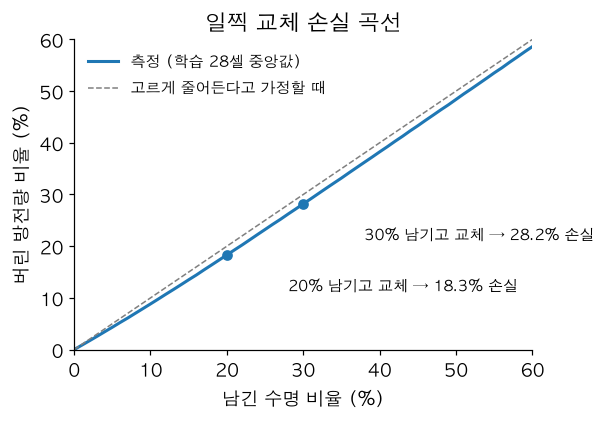

In [5]:
cells_b1 = load_cells(['b1'])
curve_tr, curve_b1 = T.value_curve(train, cells_b1), T.value_curve(b1, cells_b1)
print('남긴 수명 10/20/30/50% → 남긴 방전량 (학습 28셀):', np.round(np.interp([.1, .2, .3, .5], *curve_tr) * 100, 1), '%')
fig, ax = plt.subplots(figsize=(5.6, 4))
ax.plot(curve_tr[0] * 100, curve_tr[1] * 100, color='tab:blue', lw=2, label='측정 (학습 28셀 중앙값)')
ax.plot([0, 100], [0, 100], color='gray', ls='--', lw=1, label='고르게 줄어든다고 가정할 때')
for f in [0.2, 0.3]:
    v = np.interp(f, *curve_tr); ax.scatter(f * 100, v * 100, color='tab:blue', zorder=3)
    ax.annotate(f'{f:.0%} 남기고 교체 → {v:.1%} 손실', (f * 100, v * 100), (f * 100 + 8, v * 100 - 7), fontsize=10)
ax.set_xlim(0, 60); ax.set_ylim(0, 60); ax.set_xlabel('남긴 수명 비율 (%)'); ax.set_ylabel('버린 방전량 비율 (%)')
ax.set_title('일찍 교체 손실 곡선'); ax.legend(frameon=False, fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / 'm1_energy_value_curve.png', dpi=200, bbox_inches='tight'); plt.show()

## 5. R별 선택 — 학습 데이터만으로
R마다 학습 28셀 교차검증 예측으로 손실이 최소인 여유 배율과 모델을 고른다. 최종 배율은 B1 36셀 교차검증으로 다시 구한다.

In [6]:
sel = T.select_by_cost(P, train, b1, curve_tr, curve_b1)
sel.round(3)

,R,선택 모델,여유 배율 (학습 28셀),"여유 배율 (최종, B1 36셀)"
0,0.1,선형회귀 (ΔQ 분산 + qd_slope_2_100 + ir_min + tavg_m...,1.055,1.102
1,0.2,선형회귀 (ΔQ 분산 + dq_skew + qd_slope_2_100),0.924,0.959
2,0.3,선형회귀 (ΔQ 분산 + dq_skew + qd_slope_2_100),0.924,0.885
3,0.4,선형회귀 (ΔQ 분산),0.888,0.898
4,0.5,선형회귀 (ΔQ 분산),0.888,0.898
5,0.6,선형회귀 (ΔQ 분산),0.888,0.898
6,0.7,선형회귀 (ΔQ 분산),0.888,0.898
7,0.8,선형회귀 (ΔQ 분산),0.888,0.898
8,0.9,선형회귀 (ΔQ 분산),0.888,0.898
9,1.0,선형회귀 (ΔQ 분산),0.888,0.898


## 6. 테스트 — 선택이 끝난 뒤 보고 대상 모델만 B2 · B3에 적용
보고 대상 = 기준선 + 계열별 최선(학습 교차검증) + R별로 선택된 모델. 모두 B1 36셀로 다시 학습한 최종 모델이다.

In [7]:
report = [T.BASELINE] + [n for n in acc.groupby('계열', sort=False).head(1).후보 if n != T.BASELINE]
report += [n for n in sel['선택 모델'].unique() if n not in report]
F = T.final_predictions(report, cand, b1, b2, b3)
sweep = T.evaluate_sweep(sel, P, F, train, valid, b1, b2, b3, curve_tr, curve_b1)
show = ['R', '선택 모델', '여유 배율 (학습 28셀)', '여유 배율 (최종, B1 36셀)', '학습 CV 늦은 교체', '검증 늦은 교체', 'B2 늦은 교체', 'B3 늦은 교체', 'B3 평균 일찍(%)']
sweep[show].round(3)

,R,선택 모델,여유 배율 (학습 28셀),"여유 배율 (최종, B1 36셀)",학습 CV 늦은 교체,검증 늦은 교체,B2 늦은 교체,B3 늦은 교체,B3 평균 일찍(%)
0,0.1,선형회귀 (ΔQ 분산 + qd_slope_2_100 + ir_min + tavg_m...,1.055,1.102,15/28,8/8,39/39,31/44,3.496
1,0.2,선형회귀 (ΔQ 분산 + dq_skew + qd_slope_2_100),0.924,0.959,5/28,4/8,37/39,25/44,4.796
2,0.3,선형회귀 (ΔQ 분산 + dq_skew + qd_slope_2_100),0.924,0.885,5/28,4/8,32/39,15/44,8.775
3,0.4,선형회귀 (ΔQ 분산),0.888,0.898,2/28,2/8,33/39,12/44,11.192
4,0.5,선형회귀 (ΔQ 분산),0.888,0.898,2/28,2/8,33/39,12/44,11.192
5,0.6,선형회귀 (ΔQ 분산),0.888,0.898,2/28,2/8,33/39,12/44,11.192
6,0.7,선형회귀 (ΔQ 분산),0.888,0.898,2/28,2/8,33/39,12/44,11.192
7,0.8,선형회귀 (ΔQ 분산),0.888,0.898,2/28,2/8,33/39,12/44,11.192
8,0.9,선형회귀 (ΔQ 분산),0.888,0.898,2/28,2/8,33/39,12/44,11.192
9,1.0,선형회귀 (ΔQ 분산),0.888,0.898,2/28,2/8,33/39,12/44,11.192


- "평균 일찍(%)" = 셀마다 max(실제 수명 − 보정 후 예측, 0) ÷ 실제 수명의 평균. 늦게 교체한 셀은 0으로 포함한다
- 검증 8셀에는 학습용 배율, B2 · B3에는 최종 배율을 곱했다

손실 최소화로 골랐으므로 **셀당 손실**(교체비 단위)도 같이 본다. 기준선은 ΔQ 선형회귀에 같은 R의 최적 배율을 곱한 것이다.

In [8]:
loss_cols = ['R', '선택 모델'] + [f'{s} 셀당 손실{t}' for s in ['학습 CV', '검증', 'B2', 'B3'] for t in ['', ' (기준선)']]
sweep.loc[sweep.R.isin([0.1, 0.3, 0.5, 1.0, 1.1, 1.5, 2.0, 3.0, 5.0, 10.0]), loss_cols].round(3)

,R,선택 모델,학습 CV 셀당 손실,학습 CV 셀당 손실 (기준선),검증 셀당 손실,검증 셀당 손실 (기준선),B2 셀당 손실,B2 셀당 손실 (기준선),B3 셀당 손실,B3 셀당 손실 (기준선)
0,0.1,선형회귀 (ΔQ 분산 + qd_slope_2_100 + ir_min + tavg_m...,0.070,0.071,0.100,0.080,0.100,0.099,0.103,0.104
2,0.3,선형회귀 (ΔQ 분산 + dq_skew + qd_slope_2_100),0.122,0.123,0.169,0.134,0.254,0.265,0.182,0.185
4,0.5,선형회귀 (ΔQ 분산),0.138,0.138,0.184,0.184,0.434,0.434,0.239,0.239
9,1.0,선형회귀 (ΔQ 분산),0.173,0.173,0.309,0.309,0.857,0.857,0.376,0.376
10,1.1,"ElasticNet (alpha=0.03, l1=0.9)",0.178,0.180,0.143,0.334,0.910,0.942,0.260,0.403
14,1.5,"ElasticNet (alpha=0.03, l1=0.9)",0.178,0.209,0.143,0.434,1.197,0.812,0.266,0.294
19,2.0,"ElasticNet (alpha=0.03, l1=0.9)",0.178,0.234,0.143,0.184,1.581,1.069,0.266,0.328
29,3.0,"ElasticNet (alpha=0.03, l1=0.9)",0.178,0.234,0.143,0.184,2.350,1.581,0.266,0.396
30,5.0,"ElasticNet (alpha=0.03, l1=0.9)",0.178,0.234,0.143,0.184,3.889,2.607,0.266,0.533
31,10.0,"ElasticNet (alpha=0.03, l1=0.9)",0.178,0.234,0.143,0.184,7.735,5.171,0.266,0.873


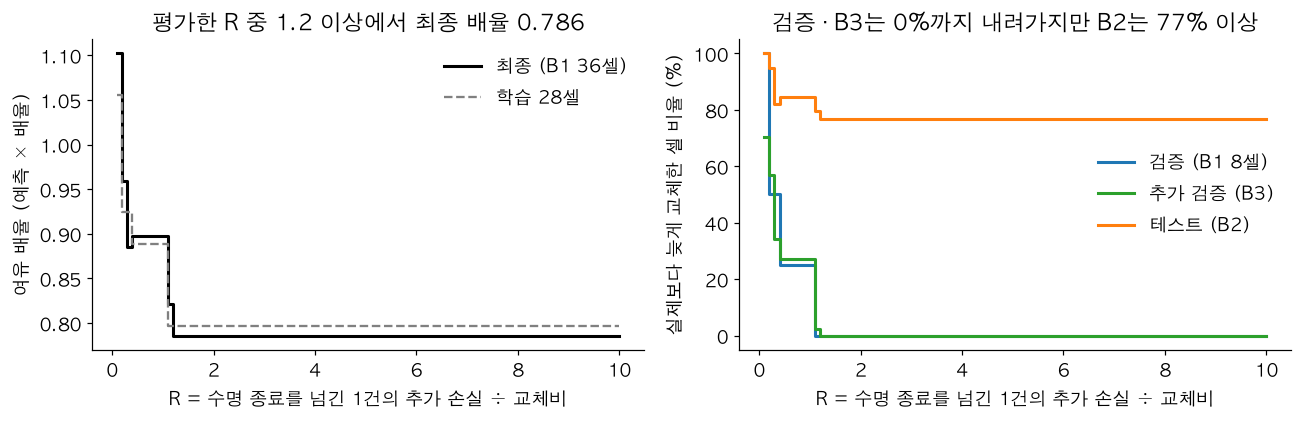

In [9]:
fin = sweep[np.isfinite(sweep.R)]
late = lambda s: s.str.split('/').str[0].astype(int) / s.str.split('/').str[1].astype(int) * 100
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].step(fin.R, fin['여유 배율 (최종, B1 36셀)'], where='post', color='black', lw=2, label='최종 (B1 36셀)')
ax[0].step(fin.R, fin['여유 배율 (학습 28셀)'], where='post', color='gray', lw=1.5, ls='--', label='학습 28셀')
ax[0].set_xlabel('R = 수명 종료를 넘긴 1건의 추가 손실 ÷ 교체비'); ax[0].set_ylabel('여유 배율 (예측 × 배율)')
ax[0].set_title('평가한 R 중 1.2 이상에서 최종 배율 0.786'); ax[0].legend(frameon=False)
for col, lab, c in [('검증 늦은 교체', '검증 (B1 8셀)', 'tab:blue'), ('B3 늦은 교체', '추가 검증 (B3)', 'tab:green'), ('B2 늦은 교체', '테스트 (B2)', 'tab:orange')]:
    ax[1].step(fin.R, late(fin[col]), where='post', lw=2, color=c, label=lab)
ax[1].set_xlabel('R = 수명 종료를 넘긴 1건의 추가 손실 ÷ 교체비'); ax[1].set_ylabel('실제보다 늦게 교체한 셀 비율 (%)')
ax[1].set_title('검증 · B3는 0%까지 내려가지만 B2는 77% 이상'); ax[1].legend(frameon=False)
plt.tight_layout(); plt.savefig(FIG_DIR / 'm2_cost_sensitivity.png', dpi=200, bbox_inches='tight'); plt.show()

**해석**
- 평가한 R 값(0.1 간격 등 33개)에서 답은 세 구간으로 나뉜다: R ≤ 0.3이면 거의 보정하지 않고, 0.4 ~ 1.0이면 최종 배율 0.898, R = 1.1이면 0.821, **평가한 R ≥ 1.2에서는 0.786**. 1.1 · 1.2 사이 등 평가하지 않은 값의 전환점은 확인하지 않았다
- R ≥ 0.4 구간에서 고른 모델은 모두 **ΔQ 분산 1개짜리 직선**이다. R ≥ 1.1의 ElasticNet도 후보 4개의 계수를 모두 0으로 만들었다 (아래 계수 출력). R ≤ 0.3에서는 후보 피처를 더한 선형회귀가 뽑혔다
- R ≥ 1.2에서 검증 0/8, B3 0/44 — 이번 관측에서는 늦은 교체가 없었다. 대가는 B3 기준 평균 28% 일찍 경고. 학습 CV 0/28은 선택에 쓴 예측이라 새 데이터의 위험률로 읽으면 안 된다 (선택 과정까지 감싼 추정은 8절)
- 손실로 보면 R ≥ 1.1의 ElasticNet은 학습 · 검증 · B3에서 기준선보다 손실이 작지만, R ≥ 1.5의 B2에서는 기준선보다 손실이 크다 (기울기가 완만해 짧은 셀을 더 길게 예측)
- **B2는 어떤 R에서도 30/39 이상 늦게 교체했다** (9절)

In [10]:
coef = {n: clone(e).fit(b1[f], b1[T.TARGET])[-1].coef_ for n, f, e in cand if n in (T.BASELINE, 'ElasticNet (alpha=0.03, l1=0.9)')}
print('ΔQ 분산 계수 (표준화 단위):', {n: round(float(c[0]), 4) for n, c in coef.items()})
print('ElasticNet (alpha=0.03, l1=0.9)의 나머지 후보 계수:', np.round(coef['ElasticNet (alpha=0.03, l1=0.9)'][1:], 4))

ΔQ 분산 계수 (표준화 단위): {'선형회귀 (ΔQ 분산)': -0.0682, 'ElasticNet (alpha=0.03, l1=0.9)': -0.0411}
ElasticNet (alpha=0.03, l1=0.9)의 나머지 후보 계수: [-0.  0.  0. -0.]


## 7. 성능 리포팅 (과제 포맷) — 모델 자체의 정확도
- 여유 배율을 곱하기 **전** 예측의 MAPE. 원논문(9.1%)과 비교하는 값이다
- Train은 학습 28셀 GroupKFold **fold별 MAPE의 평균**(± 표준편차)
- Gap은 행 이름 그대로 **앞 − 뒤**로 계산한다. MAPE는 낮을수록 좋으므로 Gap이 **(−)이면 뒤 단계에서 오차가 커졌다**는 뜻이다

In [11]:
perf = pd.concat([T.performance_table(n, P, F, train, valid, b2, b3) for n in report], axis=1)
FINAL = sel.loc[sel.R == float('inf'), '선택 모델'].iloc[0]
perf[[FINAL, T.BASELINE] + [n for n in report if n not in (FINAL, T.BASELINE)]].round(2)

,"ElasticNet (alpha=0.03, l1=0.9)",선형회귀 (ΔQ 분산),"ElasticNet (alpha=0.01, l1=0.5)","분위수 회귀 (하위 20%, ΔQ 분산)",랜덤포레스트 (비교용),LightGBM (비교용),선형회귀 (ΔQ 분산 + qd_slope_2_100 + ir_min + tavg_mean),선형회귀 (ΔQ 분산 + dq_skew + qd_slope_2_100)
"Train (B1 CV, fold 평균)",10.64,7.98,8.39,10.13,10.98,14.24,10.50,9.25
"Train (B1 CV, fold 표준편차)",1.40,3.24,2.99,1.45,3.53,1.95,3.20,2.46
Valid (B1 Hold-out),9.03,10.52,9.70,7.65,11.45,16.08,9.86,11.68
Test (B2),38.81,28.56,30.66,21.54,30.59,29.06,24.29,30.86
"Test (B3, 추가)",14.06,12.81,12.18,13.53,16.91,17.12,11.48,16.91
Gap (Train−Valid),1.61,-2.54,-1.31,2.47,-0.47,-1.84,0.65,-2.43
Gap (Valid−Test),-29.78,-18.04,-20.96,-13.89,-19.14,-12.97,-14.44,-19.18
Gap (Target−Test),-29.71,-19.46,-21.56,-12.44,-21.49,-19.96,-15.19,-21.76
"Gap (B2−B3, 추가)",24.75,15.75,18.48,8.01,13.68,11.94,12.81,13.95
"Gap (Target−Test, B3 기준)",-4.96,-3.71,-3.08,-4.43,-7.81,-8.02,-2.38,-7.81


**해석**
- **Gap (Train−Valid)** 은 −2.5 ~ +2.5%p로 작다 → 이번 분할에서 B1 안의 과적합은 크지 않다 (검증 8셀 한 번의 분할이라 강한 결론은 아니다)
- **Gap (Valid−Test)** 는 모든 모델에서 −13 ~ −30%p → 배치가 바뀌면 오차가 크게 커진다. 다만 Valid는 학습 28셀 모델, Test는 B1 36셀로 다시 학습한 모델의 결과라 재학습 효과도 조금 섞여 있다
- B3에서는 MAPE 11 ~ 17%로 B2보다 훨씬 낫다. B3 기준 원논문 대비 Gap은 −2.4 ~ −8.0%p
- B2에서 초기 데이터가 불안정한 8셀을 빼도 MAPE는 비슷하거나 오히려 높다 → B2 오차는 그 8셀만으로는 설명되지 않는다 (배치 전체에 공통된 측정 차이까지 배제한 것은 아니다)
- 최종 ElasticNet은 ΔQ 기울기를 기준선의 약 60%로 줄인 **완만한 직선**이다. 학습 범위 안에서는 여유 손실이 가장 작았지만, 짧은 수명 쪽으로 덜 내려가 짧은 셀이 많은 B2에서 MAPE 38.8%로 가장 나빴다. 테스트를 본 뒤 모델을 바꾸면 누수이므로 바꾸지 않고 그대로 보고한다

## 8. 중첩 교차검증 — 선택 과정까지 포함한 B1 안 성능
위 결과는 같은 교차검증 예측으로 모델과 배율을 고르고 그 성과를 다시 본 것이라 낙관적일 수 있다.
그래서 B1 36셀을 바깥 5묶음(충전 방식 단위)으로 나누고, 바깥 학습 부분에서 **피처 조합 · 모델 · 여유 배율 선택을 처음부터 다시** 한 뒤,
처음 보는 충전 방식의 바깥 셀에 적용했다.

In [12]:
nest, nest_acc = T.nested_cv(cand, b1, cells_b1)
print('정확도(MAPE) 기준 선택 — 바깥 fold별')
print(nest_acc.round(2).to_string(index=False))
print('선택 과정 포함 B1 MAPE (셀 수 가중 평균): %.2f%%' % np.average(nest_acc.MAPE, weights=nest_acc.n))
nest[['R', '늦은_교체', '셀', '평균_일찍', '셀당_손실', '배율_최소', '배율_최대']].round(3)

정확도(MAPE) 기준 선택 — 바깥 fold별
 fold                             선택 모델 (MAPE 기준)  MAPE  n
    0 선형회귀 (ΔQ 분산 + dq_skew + ir_min + tavg_mean) 14.22  8
    1               선형회귀 (ΔQ 분산 + qd_slope_2_100) 16.39  7
    2                                선형회귀 (ΔQ 분산) 10.71  7
    3                      선형회귀 (ΔQ 분산 + dq_skew)  9.84  7
    4                      선형회귀 (ΔQ 분산 + dq_skew)  8.62  7
선택 과정 포함 B1 MAPE (셀 수 가중 평균): 12.02%


,R,늦은_교체,셀,평균_일찍,셀당_손실,배율_최소,배율_최대
0,0.1,21,36,1.986,0.076,1.000,1.065
1,0.2,11,36,8.123,0.135,0.912,0.990
2,0.3,6,36,10.089,0.141,0.898,0.990
3,0.4,5,36,10.251,0.148,0.898,0.990
4,0.5,5,36,10.251,0.162,0.898,0.990
5,0.6,5,36,10.619,0.180,0.888,0.990
6,0.7,5,36,12.142,0.208,0.841,0.990
7,0.8,5,36,12.454,0.225,0.815,0.990
8,0.9,5,36,12.454,0.239,0.815,0.990
9,1.0,4,36,14.587,0.245,0.810,0.990


- **정확도**: 선택 과정까지 포함하면 B1 안 MAPE는 약 12.0%다. 학습 교차검증 최선값(7.98%)보다 높다 → 34개 후보 중 고르는 과정에서 약 4%p가 낙관적으로 나왔다. 바깥 fold마다 고른 피처 조합도 달랐다
- **늦은 교체**: R ≥ 1.4에서 처음 보는 충전 방식의 셀 36개 중 3개(8%)가 늦게 교체됐다. 학습 CV 0/28 · 검증 0/8은 낙관적인 숫자이고, B1 안에서도 늦은 교체가 약 8% 남을 수 있다는 것이 더 정직한 추정이다

## 9. 예측 vs 실제 — 평가한 R ≥ 1.2 구간의 최종 모델 + 여유 배율

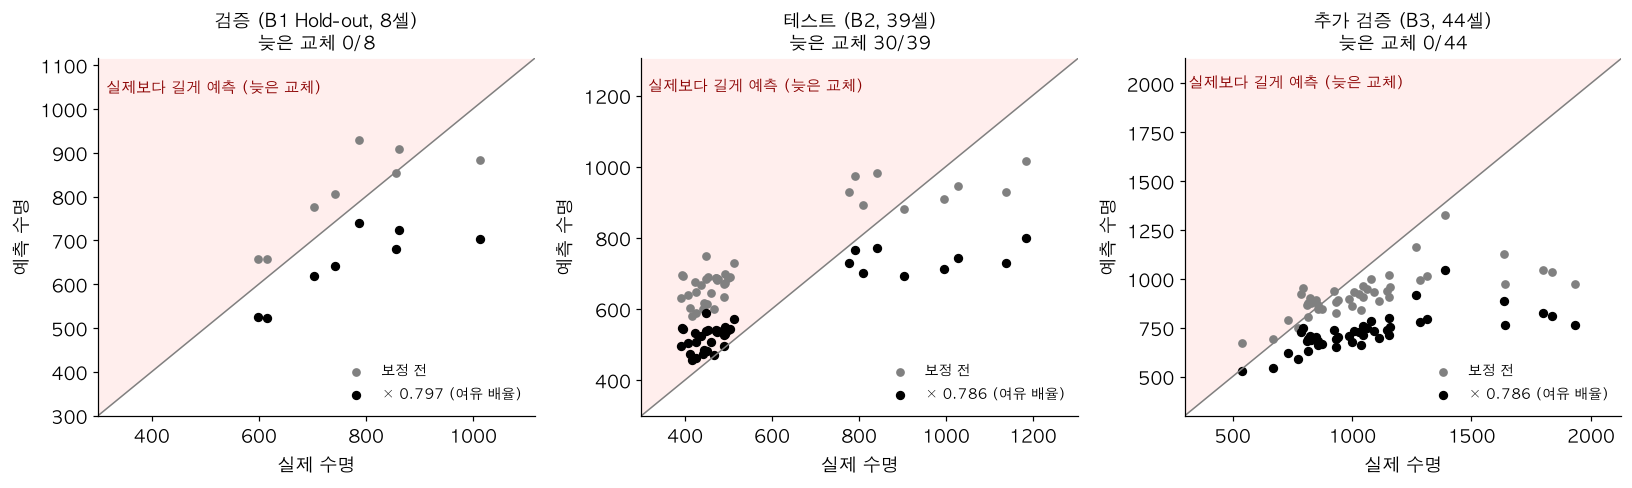

In [13]:
m_tr = sel.loc[sel.R == float('inf'), '여유 배율 (학습 28셀)'].iloc[0]
m_b1 = sel.loc[sel.R == float('inf'), '여유 배율 (최종, B1 36셀)'].iloc[0]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
for a, (name, y, p, m) in zip(ax, [('검증 (B1 Hold-out, 8셀)', valid.cycle_life, P[FINAL]['valid'], m_tr),
                                    ('테스트 (B2, 39셀)', b2.cycle_life, F[FINAL]['b2'], m_b1),
                                    ('추가 검증 (B3, 44셀)', b3.cycle_life, F[FINAL]['b3'], m_b1)]):
    lo, hi = 300, max(y.max(), p.max()) * 1.1
    a.fill_between([lo, hi], [lo, hi], [hi, hi], color='mistyrose', alpha=0.6, lw=0)
    a.text(lo * 1.05, hi * 0.93, '실제보다 길게 예측 (늦은 교체)', color='darkred', fontsize=10)
    a.plot([lo, hi], [lo, hi], color='gray', lw=1)
    a.scatter(y, p, s=22, color='gray', label='보정 전')
    a.scatter(y, p * m, s=26, color='black', label=f'× {m:.3f} (여유 배율)')
    a.set_xlim(lo, hi); a.set_ylim(lo, hi); a.set_xlabel('실제 수명'); a.set_ylabel('예측 수명')
    a.set_title(f'{name}\n늦은 교체 {(p * m > y).sum()}/{len(y)}', fontsize=12); a.legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout(); plt.savefig(FIG_DIR / 'm3_pred_vs_actual.png', dpi=200, bbox_inches='tight'); plt.show()

## 10. 오류 분석 — B2에서 크게 틀린 셀의 공통점

In [14]:
e2 = b2[['cell_id', 'policy', 'cycle_life', 'dq_var_log', 'c1', 'c2', 'early_data_ok']].copy()
e2['newstructure'] = e2.policy.str.contains('newstructure')
for n, tag in [(T.BASELINE, '기준선'), (FINAL, '최종')]:
    e2[f'예측_{tag}'] = F[n]['b2']
    e2[f'오차_{tag}(%)'] = (F[n]['b2'] - e2.cycle_life) / e2.cycle_life * 100
print('가장 크게 틀린 8셀 — 최종 모델(ElasticNet) 기준, 여유 배율 적용 전')
e2.reindex(e2['오차_최종(%)'].abs().sort_values(ascending=False).index).head(8)[
    ['cell_id', 'policy', 'cycle_life', '예측_최종', '오차_최종(%)', '오차_기준선(%)', 'newstructure', 'early_data_ok']].round(1)

가장 크게 틀린 8셀 — 최종 모델(ElasticNet) 기준, 여유 배율 적용 전


,cell_id,policy,cycle_life,예측_최종,오차_최종(%),오차_기준선(%),newstructure,early_data_ok
6,b2c6,3.6C(9%)-5C,393.0,695.9,77.1,64.9,False,True
15,b2c15,3.6C(9%)-5C,396.0,691.9,74.7,62.1,False,True
18,b2c18,5.2C(50%)-4.25C,449.0,748.6,66.7,63.0,False,True
19,b2c19,6C(60%)-3C,392.0,630.8,60.9,40.5,False,True
2,b2c2,5.2C(50%)-4.25C,424.0,676.1,59.5,45.7,False,False
21,b2c21,6C(60%)-3C,408.0,639.9,56.8,38.2,False,False
27,b2c29,5.2C(58%)-4C,452.0,689.6,52.6,41.3,False,True
26,b2c28,4.8C(80%)-4.8C,437.0,665.9,52.4,37.9,False,True


In [15]:
for tag in ['기준선', '최종']:
    top = e2.reindex(e2[f'오차_{tag}(%)'].abs().sort_values(ascending=False).index).head(8)
    print(f'{tag} 모델 상위 8셀 중 newstructure 표기 없는 셀: {(~top.newstructure).sum()} / 8')
g = e2.groupby('newstructure').agg(셀=('cell_id', 'size'), 수명_최소=('cycle_life', 'min'), 수명_최대=('cycle_life', 'max'),
                                   수명_중앙값=('cycle_life', 'median'), 기준선_오차_중앙값=('오차_기준선(%)', 'median'),
                                   최종_오차_중앙값=('오차_최종(%)', 'median'), 품질_통과=('early_data_ok', 'sum'))
print('충전 속도와 기준선 오차의 상관: C1 r = %.2f, C2 r = %.2f' % (e2[['오차_기준선(%)', 'c1']].corr().iloc[0, 1], e2[['오차_기준선(%)', 'c2']].corr().iloc[0, 1]))
short = e2[~e2.newstructure]
lo_, hi_ = b1.dq_var_log.min(), b1.dq_var_log.max()
print(f'표기 없는 30셀 중 ΔQ 분산이 학습 범위({lo_:.2f} ~ {hi_:.2f}) 안: {short.dq_var_log.between(lo_, hi_).sum()} / {len(short)}')
same = e2[e2.policy.str.replace('-newstructure', '').isin(e2[e2.newstructure].policy.str.replace('-newstructure', ''))]
print('\n같은 충전 방식, 구조 표기만 다른 셀 (수명 중앙값)')
print(same.assign(방식=same.policy.str.replace('-newstructure', '')).groupby(['방식', 'newstructure']).cycle_life.agg(['count', 'median']).to_string())
g.round(1)

기준선 모델 상위 8셀 중 newstructure 표기 없는 셀: 7 / 8
최종 모델 상위 8셀 중 newstructure 표기 없는 셀: 8 / 8
충전 속도와 기준선 오차의 상관: C1 r = -0.15, C2 r = -0.17
표기 없는 30셀 중 ΔQ 분산이 학습 범위(-4.18 ~ -3.35) 안: 19 / 30

같은 충전 방식, 구조 표기만 다른 셀 (수명 중앙값)
                             count  median
방식             newstructure               
4.8C(80%)-4.8C False             5   492.0
               True              3   809.0
5.2C(58%)-4C   False             4   483.0
               True              3   904.0
5.6C(26%)-4.5C False             6   446.0
               True              3   997.0


,셀,수명_최소,수명_최대,수명_중앙값,기준선_오차_중앙값,최종_오차_중앙값,품질_통과
newstructure,,,,,,,
False,30,392.0,514.0,451.0,32.2,43.6,25
True,9,777.0,1186.0,904.0,6.1,-2.5,6


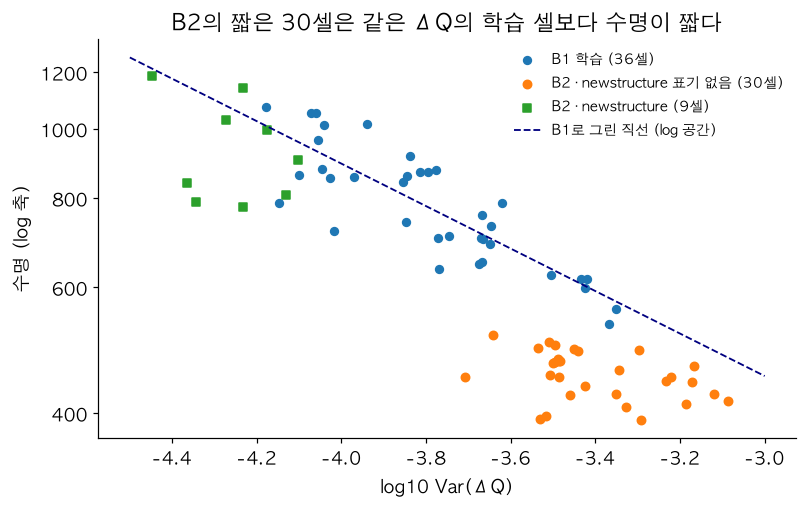

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
fit = np.polyfit(b1.dq_var_log, np.log10(b1.cycle_life), 1)
ax.scatter(b1.dq_var_log, b1.cycle_life, s=26, color='tab:blue', label='B1 학습 (36셀)')
for flag, c, lab in [(False, 'tab:orange', 'B2 · newstructure 표기 없음 (30셀)'), (True, 'tab:green', 'B2 · newstructure (9셀)')]:
    d = e2[e2.newstructure == flag]; ax.scatter(d.dq_var_log, d.cycle_life, s=30, color=c, label=lab, marker='s' if flag else 'o')
xs = np.linspace(-4.5, -3.0, 50); ax.plot(xs, 10 ** np.polyval(fit, xs), color='navy', ls='--', lw=1.2, label='B1로 그린 직선 (log 공간)')
ax.set_yscale('log'); ax.set_yticks([400, 600, 800, 1000, 1200]); ax.set_yticklabels(['400', '600', '800', '1000', '1200']); ax.minorticks_off()
ax.set_xlabel('log10 Var(ΔQ)'); ax.set_ylabel('수명 (log 축)')
ax.set_title('B2의 짧은 30셀은 같은 ΔQ의 학습 셀보다 수명이 짧다'); ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / 'm4_error_b2_structure.png', dpi=200, bbox_inches='tight'); plt.show()

**오류 분석 결과**
- **공통점**: 기준선 · 최종 모델 모두 크게 틀린 셀은 대부분 충전 방식 이름에 `newstructure` 표기가 **없는** 셀이다. 표기 없는 30셀은 수명 392 ~ 514로 전부 학습 최솟값(534) 아래이고, 표기가 있는 9셀은 777 ~ 1,186이다. 최종 모델은 기울기가 완만해 이 30셀을 기준선보다 더 길게 예측했다
- **기록된 충전 조건으로는 설명되지 않는다**: 같은 명목 충전 방식인데 표기 유무에 따라 수명이 약 2배 다르고, 오차와 C1 · C2의 상관은 |r| < 0.2다. 다만 기록되지 않은 충전 관련 요인까지 배제할 수는 없다
- **곡선 변화와 수명의 관계가 다르다**: 짧은 30셀 중 19셀은 ΔQ 분산이 학습 셀과 같은 범위에 있는데, 같은 ΔQ의 학습 셀이 약 600 사이클을 사는 동안 이 셀들은 약 450에서 끝났다
- **급변 8셀만으로는 설명되지 않는다**: 초기 데이터가 불안정한 8셀은 두 무리에 섞여 있고, 빼도 B2 오차가 줄지 않는다 (7절). 배치 전체에 공통된 측정 차이는 배제하지 못했다
- **원인 가설**: `newstructure`는 원본 충전 방식 문자열에 붙은 표기로, 데이터 설명에 의미가 없어 확인하지 못했다. 표기와 관련된 실험 구조 차이, 생산 로트, B2 배치의 측정 조건(2절의 Qdlin 차이) 등 **배치 관련 차이가 유력한 가설**이다. 확정하려면 실험 기록이 필요하다
- **개선 방향**: ① 새 배치 · 로트가 들어오면 일부 셀을 수명 끝까지 돌려 여유 배율을 다시 맞춘다 ② 실험 · 생산 메타데이터를 피처로 기록한다 ③ 학습에 여러 배치를 섞어 배치 차이를 모델이 보게 한다. 테스트 결과를 본 뒤의 개선이므로 이번 모델에는 반영하지 않았다